<a href="https://colab.research.google.com/github/ximeniki/Stroke-prediction-ML/blob/main/VARGAS_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Load data set
!git clone https://github.com/abdelDebug/stroke_prediction.git
%cd stroke_prediction

Cloning into 'stroke_prediction'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 68.82 KiB | 3.44 MiB/s, done.
/content/stroke_prediction


In [ ]:
import pandas as pd

df = pd.read_csv("healthcare-dataset-stroke-data.csv") # Read data set
print(df.shape) # Show dataset size
df.head() # Show first rows, this will help to know if features are numerical or categorical

(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


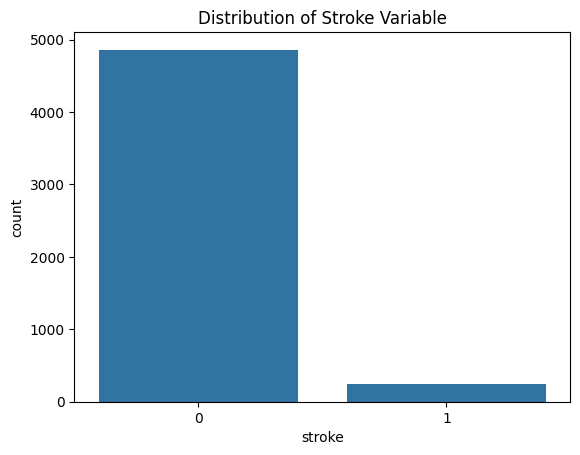

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='stroke') # Ploting distribution of target variable
plt.title("Distribution of Stroke Variable")
plt.show()

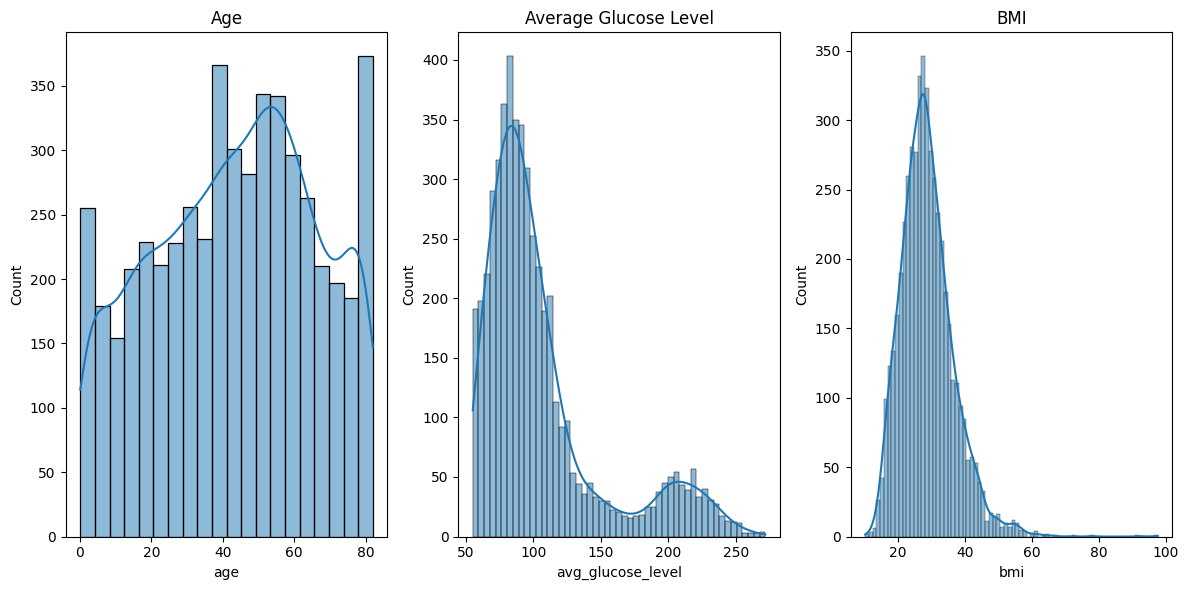

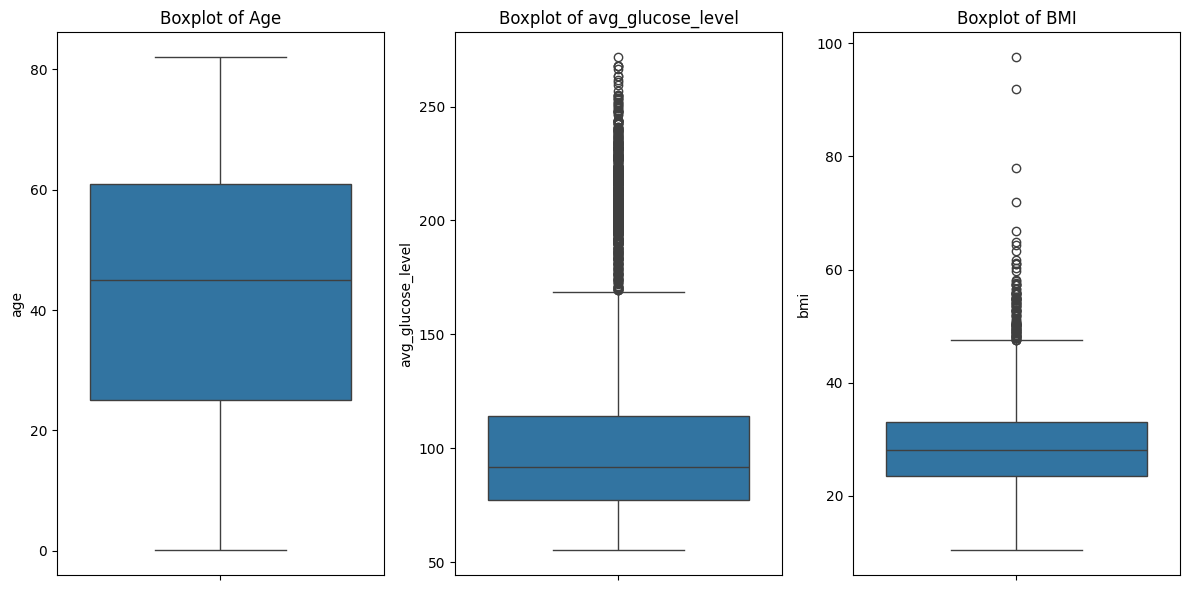

In [ ]:
numV = df[['age', 'avg_glucose_level', 'bmi']] # Defining numerical variables
catV = df[['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']] # Defining categorical variables

# Numerical variables visualizations - histogram plot and box plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.histplot(df['age'], kde=True)
plt.title('Age')

plt.subplot(1, 3, 2)
sns.histplot(df['avg_glucose_level'], kde=True)
plt.title('Average Glucose Level')

plt.subplot(1, 3, 3)
sns.histplot(df['bmi'], kde=True)
plt.title('BMI')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['age'])
plt.title('Boxplot of Age')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['avg_glucose_level'])
plt.title('Boxplot of avg_glucose_level')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['bmi'])
plt.title('Boxplot of BMI')

plt.tight_layout()
plt.show()

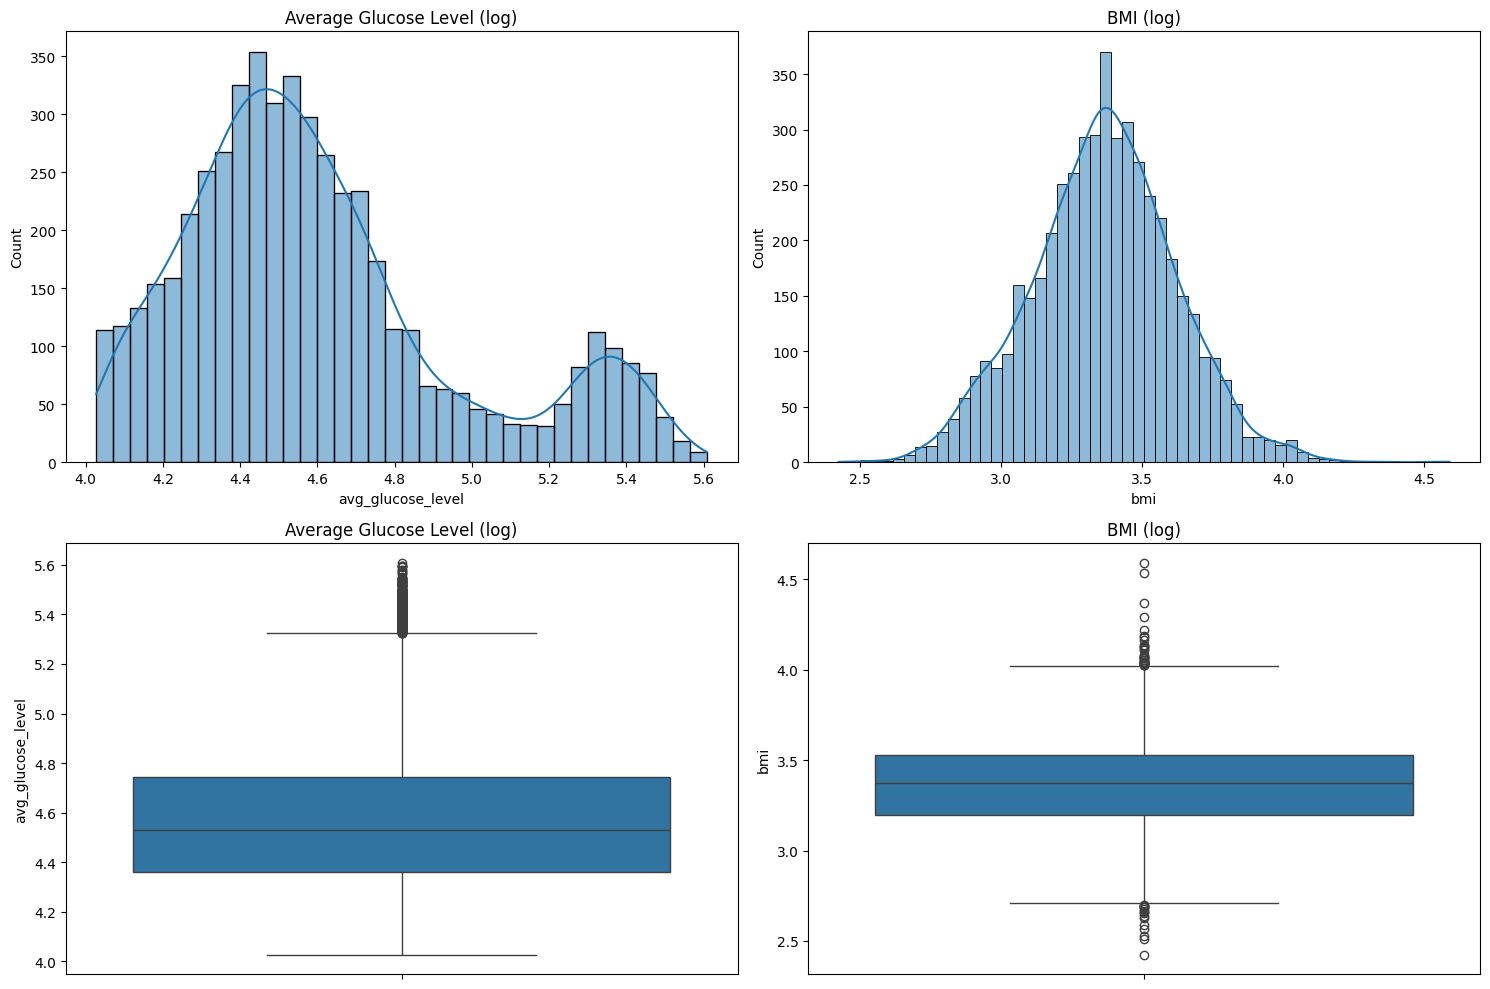

In [ ]:
import numpy as np

df_log = df.copy()# copying df so we dont modify the original

# only aplying log to bmi and glucose because age does not need it
df_log['bmi'] = np.log1p(df_log['bmi'])  # log(1+x) help with 0 values
df_log['avg_glucose_level'] = np.log1p(df_log['avg_glucose_level'])

# plotting hist and boxplot after performong log
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(df_log['avg_glucose_level'], kde=True)
plt.title('Average Glucose Level (log)')

plt.subplot(2, 2, 2)
sns.histplot(df_log['bmi'], kde=True)
plt.title('BMI (log)')

plt.subplot(2, 2, 3)
sns.boxplot(df_log['avg_glucose_level'])
plt.title('Average Glucose Level (log)')

plt.subplot(2, 2, 4)
sns.boxplot(df_log['bmi'])
plt.title('BMI (log)')

plt.tight_layout()
plt.show()

In [ ]:
print(df_log[['age', 'avg_glucose_level', 'bmi']].describe().T[['mean','std', 'min', 'max', '25%', '50%', '75%']].round(2))

                    mean    std   min    max    25%    50%    75%
age                43.23  22.61  0.08  82.00  25.00  45.00  61.00
avg_glucose_level   4.60   0.36  4.03   5.61   4.36   4.53   4.75
bmi                 3.36   0.26  2.42   4.59   3.20   3.37   3.53


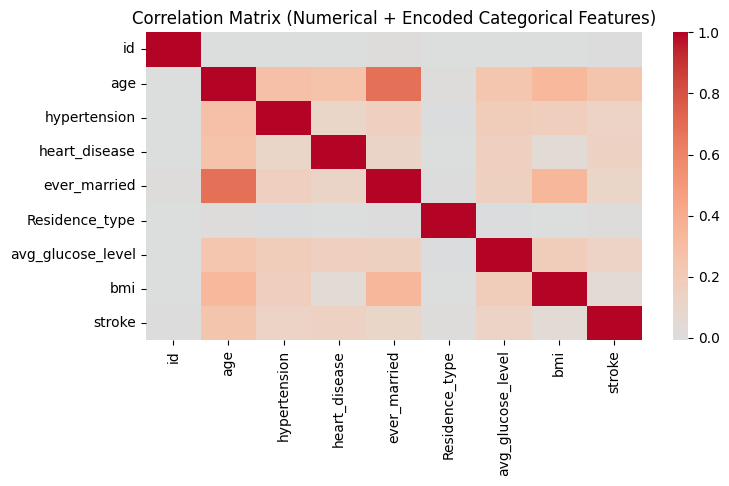


Correlation with target 'stroke':
stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
ever_married         0.108340
bmi                  0.042374
Residence_type       0.015458
id                   0.006388
Name: stroke, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

def mixed_correlation_matrix(df, target_col=None):

    df_copy = df.copy()


    categorical = df_copy.select_dtypes(include=['object']).columns.tolist()# Separate categorical and numerical columns
    numerical = df_copy.select_dtypes(include=[np.number]).columns.tolist()


    for col in categorical: # Encoding categorical columns
        if df_copy[col].nunique() == 2:
            le = LabelEncoder()
            df_copy[col] = le.fit_transform(df_copy[col].astype(str))
        else:  # one hot encoder for more than 1 category
            dummies = pd.get_dummies(df_copy[col], prefix=col, drop_first=True)
            df_copy = pd.concat([df_copy.drop(columns=[col]), dummies], axis=1)


    numerical = df_copy.select_dtypes(include=[np.number]).columns.tolist() # Recompute numerical columns after encoding


    corr_matrix = df_copy[numerical].corr() # perform Pearson correlation

    # Plotting heatmap
    plt.figure(figsize=(8,4))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
    plt.title("Correlation Matrix (Numerical + Encoded Categorical Features)")
    plt.show()


    if target_col and target_col in corr_matrix.columns:
        print("\nCorrelation with target '{}':".format(target_col))
        print(corr_matrix[target_col].sort_values(ascending=False))

    return corr_matrix

corr_matrix = mixed_correlation_matrix(df, target_col='stroke')

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd


imputer = SimpleImputer(strategy='median') #handling missing values with median strategy
df['bmi'] = imputer.fit_transform(df[['bmi']])


numerical_features = ['age', 'avg_glucose_level', 'bmi']
categorical_features = ["gender", "hypertension", "heart_disease", "ever_married", "work_type", "smoking_status"]


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)


processed_data = preprocessor.fit_transform(df.drop('stroke', axis=1)) #Transform


num_cols = numerical_features
cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_cols = list(num_cols) + list(cat_cols)

processed_df = pd.DataFrame(processed_data, columns=all_cols)
display(processed_df.head())


,age,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,hypertension_0,hypertension_1,heart_disease_0,heart_disease_1,...,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.051434,2.706375,1.005086,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.786070,2.121559,-0.098981,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.626390,-0.005028,0.472536,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.255342,1.437358,0.719327,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.582163,1.501184,-0.631531,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


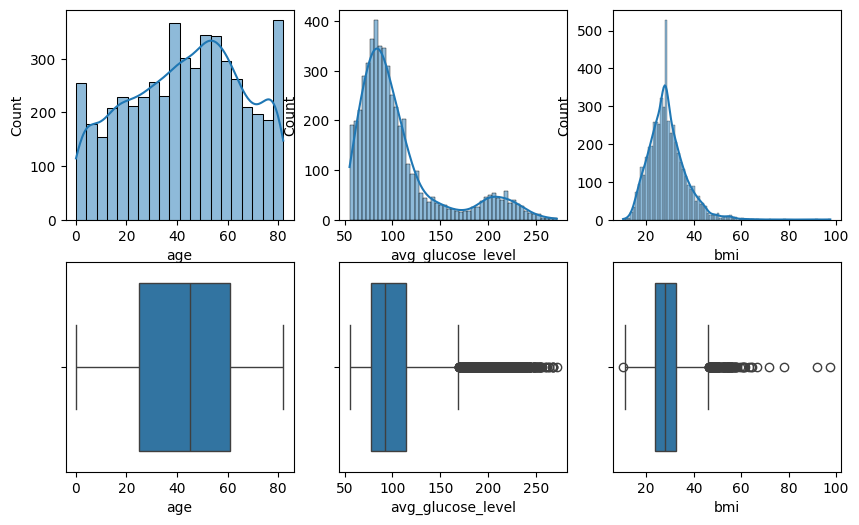

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# plotting after transforming and comparing histogram and boxplot
plt.figure(figsize=(10, 6))

for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True)

    plt.subplot(2, 3, i+4)
    sns.boxplot(x=df[col])


In [ ]:
from sklearn.model_selection import train_test_split

# splitting data for testing and training, using 25% for testing
X = processed_df
y = df['stroke'] #target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (3832, 21)
Shape of X_test: (1278, 21)
Shape of y_train: (3832,)
Shape of y_test: (1278,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from pprint import pprint


# SVM model training
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm) # calculating performing metrics
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("\n--- SVM Results ---")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-score: {f1_svm:.4f}")
print("SVM trained with default parameters:")
pprint(svm_model.get_params())

# Random Forest model training
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("\n--- Random Forest Results ---")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
pprint(rf_model.get_params())

# Logistic Regression model training
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("\n--- Logistic Regression Results ---")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")
pprint(lr_model.get_params())

# K-Nearest Neighbors model training
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("\n--- K-Nearest Neighbors Results ---")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-score: {f1_knn:.4f}")
pprint(knn_model.get_params())

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- SVM Results ---
Accuracy: 0.9374
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
SVM trained with default parameters:
{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': True,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

--- Random Forest Results ---
Accuracy: 0.9374
Precision: 0.5000
Recall: 0.0250
F1-score: 0.0476
{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

--- Logistic Regression Results ---
Accuracy: 0.9

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

trained_models = {
    "SVM": svm_model,
    "Random Forest": rf_model,
    "Logistic Regression": lr_model,
    "K-Nearest Neighbors": knn_model
}
# showing results
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    results.append({
        "Model": name,
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else None
    })

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
print(results_df)

                 Model        F1   ROC-AUC
1        Random Forest  0.047619  0.789874
2  Logistic Regression  0.024691  0.841507
0                  SVM  0.000000  0.679622
3  K-Nearest Neighbors  0.000000  0.613851


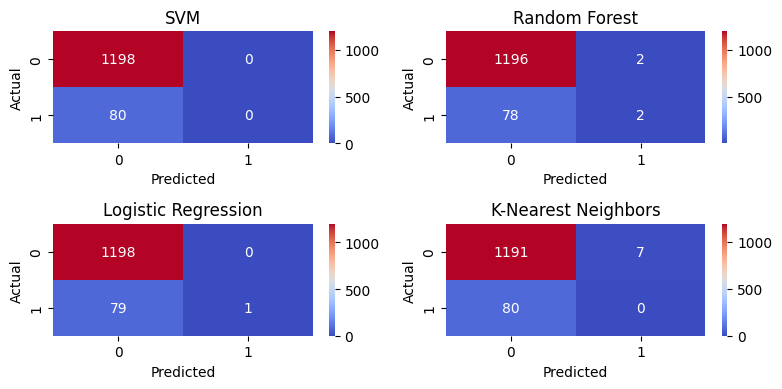

In [ ]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# heatmap for all 4 models
model_names = list(trained_models.keys())


fig, axes = plt.subplots(2, 2, figsize=(8, 4))

for i, name in enumerate(model_names):
    row = i // 2
    col = i % 2
    model = trained_models[name]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", ax=axes[row, col])
    axes[row, col].set_xlabel("Predicted")
    axes[row, col].set_ylabel("Actual")
    axes[row, col].set_title(f"{name}")

plt.tight_layout()
plt.show()

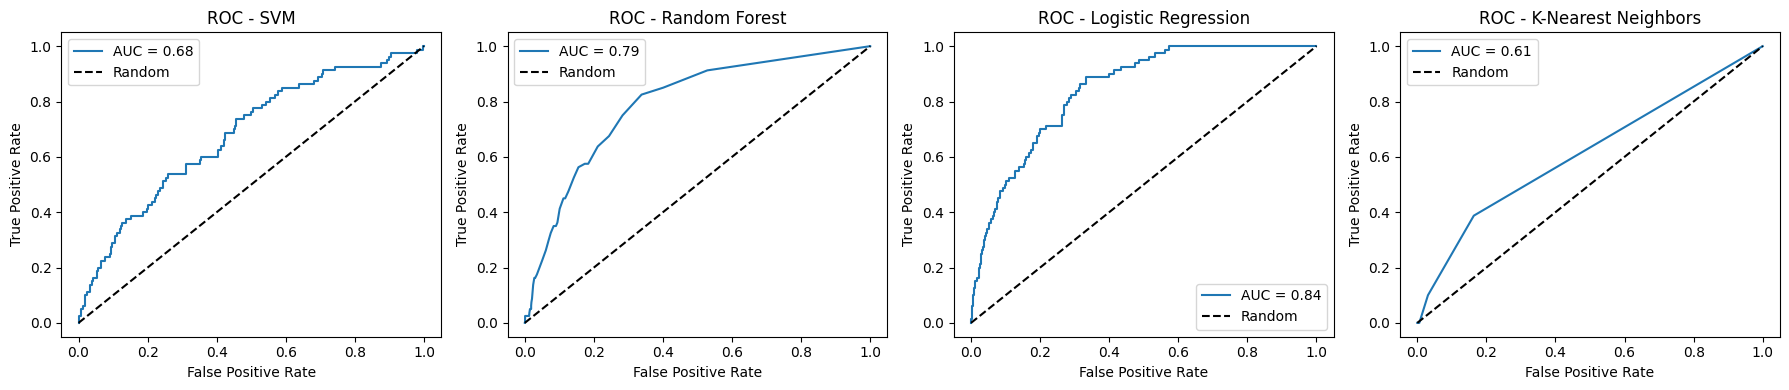

In [ ]:

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

model_names = list(trained_models.keys())

# ROC for all models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, name in zip(axes, model_names):
    y_proba = trained_models[name].predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Curva ROC
    ax.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    ax.plot([0,1], [0,1], 'k--', label='Random')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC - {name}")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pprint import pprint

# Define Logistic Regression with class wight balanced
lr_model = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)

# Hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# performing GridSearchCV
grid_search = GridSearchCV(lr_model, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

print("Best hyperparameters found by GridSearch:")
print(grid_search.best_params_)

# Best model
best_lr = grid_search.best_estimator_

# Predictions
y_pred_lr = best_lr.predict(X_test)

# Evaluation
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("\n--- Logistic Regression Results ---")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")
pprint(best_lr.get_params())

Best hyperparameters found by GridSearch:
{'C': 10, 'penalty': 'l2'}

--- Logistic Regression Results ---
Accuracy: 0.7543
Precision: 0.1676
Recall: 0.7375
F1-score: 0.2731
{'C': 10,
 'class_weight': 'balanced',
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 42,
 'solver': 'liblinear',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pprint import pprint
import numpy as np

# Random Forest with balanced class
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

# n estimators small size because we are working on colab
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# RandomizedSearchCV
rand_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist,
    n_iter=10,          # small size
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

# Training the model
rand_search.fit(X_train, y_train)

print("Best hyperparameters found by RandomizedSearch:")
print(rand_search.best_params_)

# best model
best_rf = rand_search.best_estimator_

# Predictions
y_pred_rf = best_rf.predict(X_test)

# Evaluation
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("\n--- Random Forest Results ---")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
pprint(best_rf.get_params())


Best hyperparameters found by RandomizedSearch:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}

--- Random Forest Results ---
Accuracy: 0.9319
Precision: 0.2941
Recall: 0.0625
F1-score: 0.1031
{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 20,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}


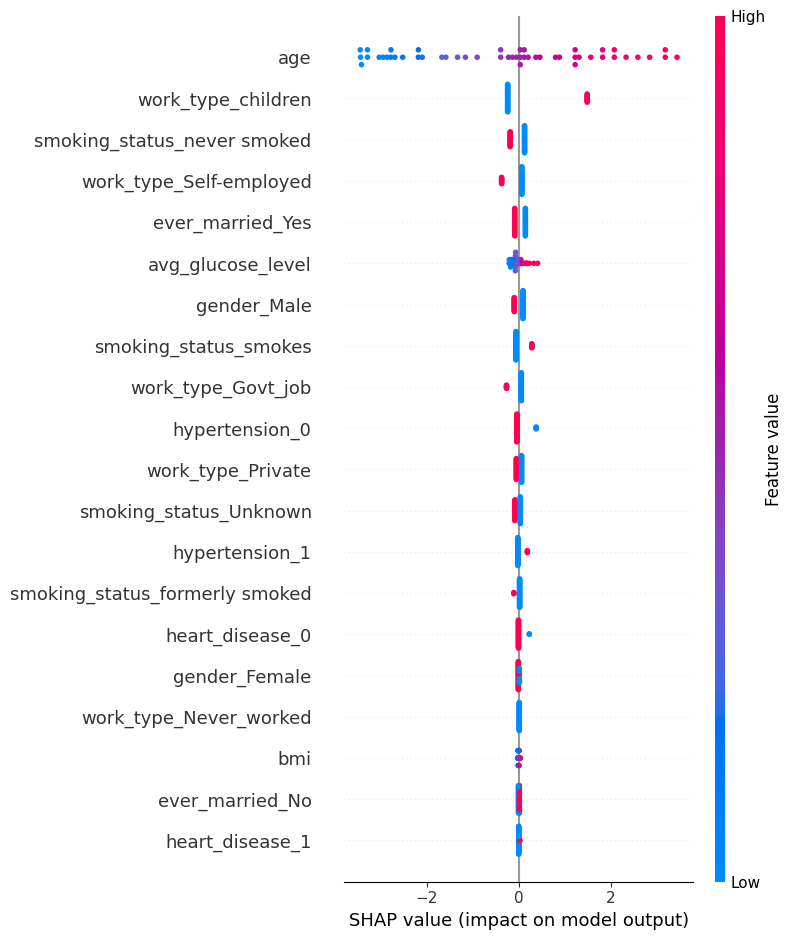

<Figure size 800x500 with 0 Axes>

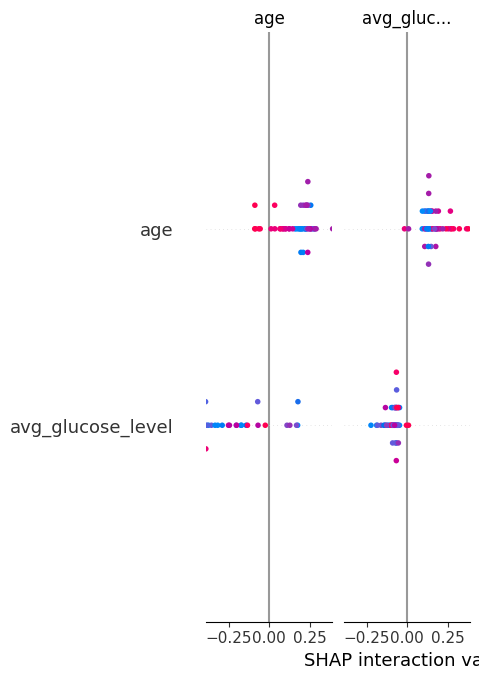

In [ ]:
import shap
import matplotlib.pyplot as plt

X_sample = X_test.iloc[:50]

#SHAP for lr
explainer_lr = shap.LinearExplainer(best_lr, X_train)
shap_values_lr = explainer_lr.shap_values(X_sample)
plt.figure(figsize=(4, 2))
shap.summary_plot(shap_values_lr, X_sample, plot_type="dot")

# SHAP for rf
explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf(X_sample)
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_rf.values, X_sample, plot_type="dot")

